# Laboratorio 5b — Clustering con K-Means
**Curso:** Minería de Datos (EIN132A25)
**Dataset:** Pokémon (Gen 1–6)

## Objetivos
- Comprender la diferencia entre aprendizaje **supervisado** y **no supervisado**
- Aplicar **K-Means** para agrupar Pokémon por sus estadísticas de combate
- Usar el **método del codo** para elegir el número óptimo de clusters
- Visualizar clusters con **PCA** (reducción a 2D)
- Interpretar qué representa cada cluster

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

url = 'pokemon.csv'
df = pd.read_csv(url)
df["Type 2"] = df["Type 2"].fillna("None")
print(f"Shape: {df.shape}")
df.head()

Shape: (800, 13)


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,None,309,39,52,43,60,50,65,1,False


## 1. Selección y preprocesamiento de features

Para clustering usamos las **6 estadísticas de combate**. Es fundamental estandarizarlas antes de aplicar K-Means, ya que el algoritmo es sensible a la escala.

In [3]:
stats_cols = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
X = df[stats_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features: {stats_cols}")
print(f"Shape: {X_scaled.shape}")
print(f"\nMedia (debe ser ~0): {X_scaled.mean(axis=0).round(4)}")
print(f"Desv. std (debe ser ~1): {X_scaled.std(axis=0).round(4)}")

Features: ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
Shape: (800, 6)

Media (debe ser ~0): [-0.  0. -0.  0. -0. -0.]
Desv. std (debe ser ~1): [1. 1. 1. 1. 1. 1.]


## 2. Método del Codo — ¿Cuántos clusters usar?

El método del codo entrena K-Means con distintos valores de k y mide la **inercia** (suma de distancias al centroide). El punto donde la curva "dobla" indica el k óptimo.

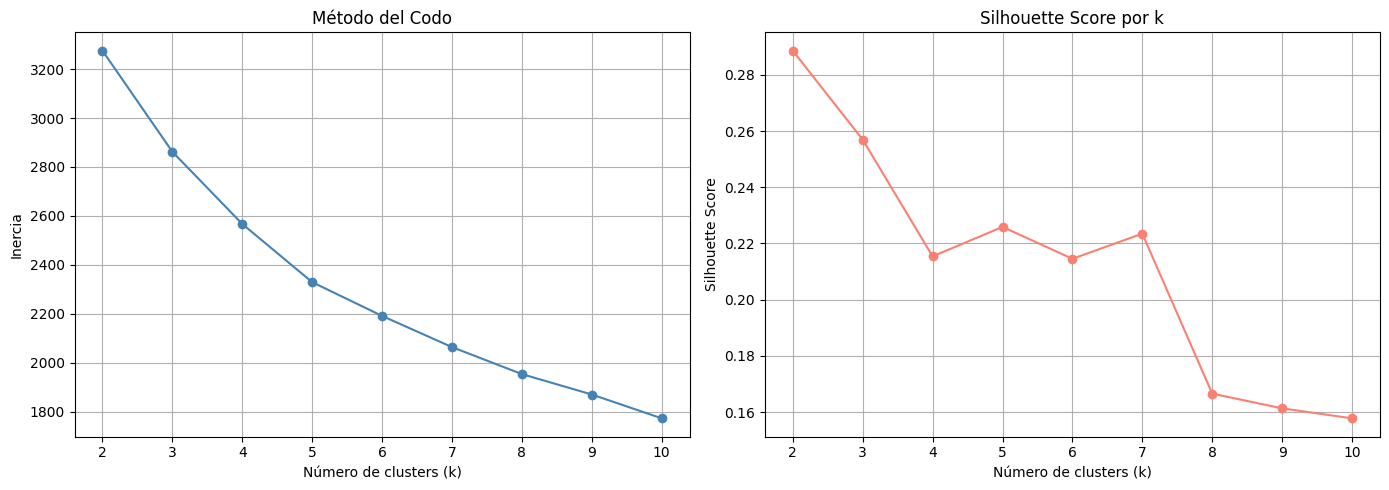


Silhouette scores:
  k=2: 0.2886
  k=3: 0.2569
  k=4: 0.2154
  k=5: 0.2259
  k=6: 0.2146
  k=7: 0.2235
  k=8: 0.1666
  k=9: 0.1614
  k=10: 0.1578


In [4]:
inercias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inercias, marker="o", color="steelblue")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia")
axes[0].set_title("Método del Codo")
axes[0].grid(True)

axes[1].plot(k_range, silhouettes, marker="o", color="salmon")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score por k")
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\nSilhouette scores:")
for k, s in zip(k_range, silhouettes):
    print(f"  k={k}: {s:.4f}")

## 3. Entrenar K-Means con k óptimo

In [ ]:
K_OPTIMO = 4  # Ajusta según la gráfica del codo

kmeans = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)

# y_pred = kmeans.predict(X_scaled)
# df["Cluster"] = y_pred

df["Cluster"] = kmeans.fit_predict(X_scaled)

print(f"K-Means entrenado con k={K_OPTIMO}")
print(f"Inercia final: {kmeans.inertia_:.2f}")
print(f"\nTamaño de cada cluster:")
print(df["Cluster"].value_counts().sort_index())

K-Means entrenado con k=4
Inercia final: 2566.78

Tamaño de cada cluster:
Cluster
0    198
1    279
2    200
3    123
Name: count, dtype: int64


## 4. Visualización con PCA (2D)

Usamos PCA para reducir las 6 dimensiones a 2 y poder visualizar los clusters.

In [ ]:
pca = PCA(n_components=5, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]
df["PC3"] = X_pca[:, 2]

varianza = pca.explained_variance_ratio_
print(f"Varianza explicada: PC1={varianza[0]*100:.1f}%, PC2={varianza[1]*100:.1f}%")
print(f"Total: {sum(varianza)*100:.1f}%")

Varianza explicada: PC1=45.2%, PC2=18.2%
Total: 95.5%


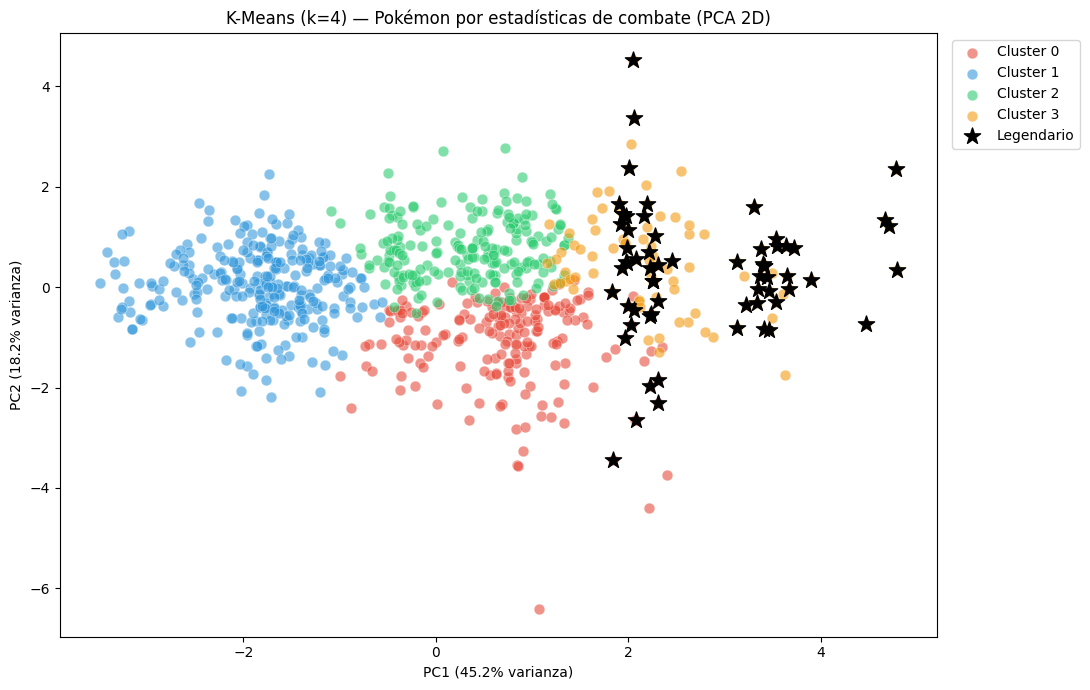

In [ ]:
colores = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6", "#1abc9c"]
cluster_colors = [colores[c] for c in df["Cluster"]]

plt.figure(figsize=(11, 7))

for cluster_id in range(K_OPTIMO):
    mask = df["Cluster"] == cluster_id
    plt.scatter(df.loc[mask, "PC1"], df.loc[mask, "PC2"],
                c=colores[cluster_id], label=f"Cluster {cluster_id}",
                alpha=0.6, edgecolors="white", linewidths=0.4, s=60)

# Marcar legendarios con una estrella
mask_leg = df["Legendary"] == True
plt.scatter(df.loc[mask_leg, "PC1"], df.loc[mask_leg, "PC2"],
            marker="*", c="black", s=150, label="Legendario", zorder=5)

plt.xlabel(f"PC1 ({varianza[0]*100:.1f}% varianza)")
plt.ylabel(f"PC2 ({varianza[1]*100:.1f}% varianza)")
plt.title(f"K-Means (k={K_OPTIMO}) — Pokémon por estadísticas de combate (PCA 2D)")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
!pip install plotly --quiet
import plotly.express as px

df["Grupo"] = df.apply(
    lambda r: "Legendario" if r["Legendary"] else f"Cluster {r['Cluster']}", axis=1
)

color_map = {
    "Cluster 0": "#e74c3c",
    "Cluster 1": "#3498db",
    "Cluster 2": "#2ecc71",
    "Cluster 3": "#f39c12",
    "Legendario": "#000000",
}

symbol_map = {
    "Cluster 0": "circle",
    "Cluster 1": "circle",
    "Cluster 2": "circle",
    "Cluster 3": "circle",
    "Legendario": "diamond",
}

fig3d = px.scatter_3d(
    df,
    x="PC1", y="PC2", z="PC3",
    color="Grupo",
    symbol="Grupo",
    hover_name="Name",
    hover_data={"Type 1": True, "Total": True, "HP": True,
                "Attack": True, "Defense": True, "PC1": False, "PC2": False, "PC3": False},
    color_discrete_map=color_map,
    symbol_map=symbol_map,
    title=f"K-Means (k={K_OPTIMO}) — Pokémon PCA 3D (interactivo)",
    opacity=0.75,
)

fig3d.update_traces(marker=dict(size=5, line=dict(width=0.5, color="white")))
fig3d.update_layout(
    legend_title_text="Grupo",
    scene=dict(
        xaxis_title=f"PC1 ({varianza[0]*100:.1f}%)",
        yaxis_title=f"PC2 ({varianza[1]*100:.1f}%)",
        zaxis_title=f"PC3 ({varianza[2]*100:.1f}%)",
    )
)

fig3d.show()
fig3d.write_html("pokemon_clusters_3d.html")

## 5. Análisis de los clusters

¿Qué tipo de Pokémon hay en cada cluster?

In [ ]:
# Estadísticas medias por cluster
resumen = df.groupby("Cluster")[stats_cols + ["Total"]].mean().round(1)
print("Estadísticas promedio por cluster:")
resumen

Estadísticas promedio por cluster:


,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Total
Cluster,,,,,,,
0,81.7,85.6,102.3,74.1,88.8,52.9,485.4
1,50.0,53.7,52.0,47.7,49.1,49.1,301.6
2,71.6,83.7,65.3,77.6,71.2,91.4,460.7
3,89.1,118.1,91.6,120.0,97.6,99.0,615.4


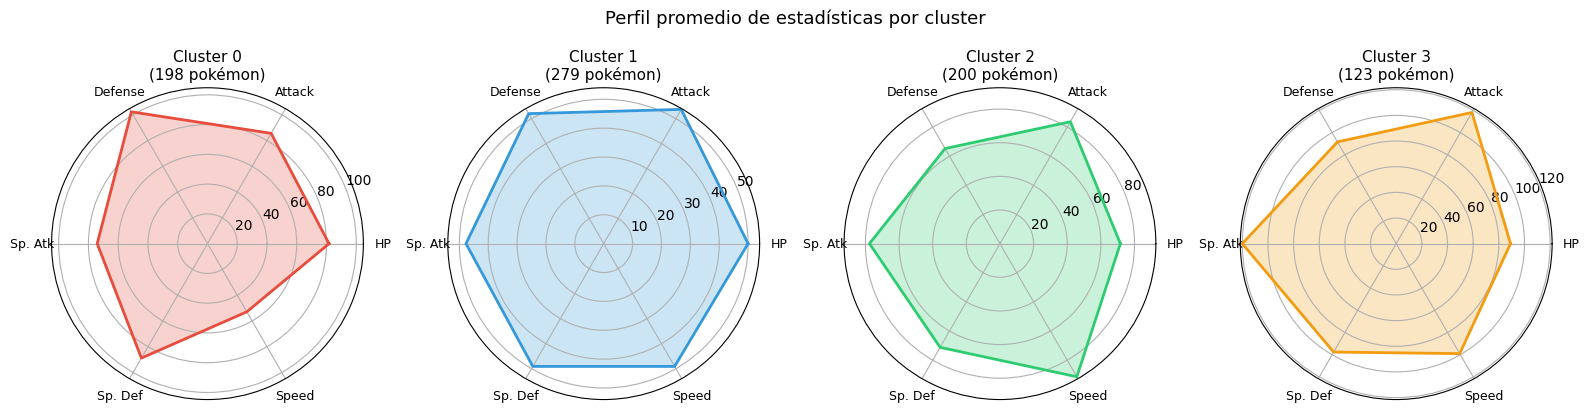

In [18]:
# Radar chart — perfil de cada cluster
from matplotlib.patches import FancyArrowPatch

categorias = stats_cols
N = len(categorias)
angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1]

fig, axes = plt.subplots(1, K_OPTIMO, figsize=(4 * K_OPTIMO, 4), subplot_kw=dict(polar=True))
if K_OPTIMO == 1:
    axes = [axes]

for i, (cluster_id, row) in enumerate(resumen.iterrows()):
    valores = row[stats_cols].values.tolist()
    valores += valores[:1]
    axes[i].plot(angulos, valores, color=colores[i], linewidth=2)
    axes[i].fill(angulos, valores, color=colores[i], alpha=0.25)
    axes[i].set_xticks(angulos[:-1])
    axes[i].set_xticklabels(categorias, size=9)
    n_pok = (df["Cluster"] == cluster_id).sum()
    axes[i].set_title(f"Cluster {cluster_id}\n({n_pok} pokémon)", size=11)

plt.suptitle("Perfil promedio de estadísticas por cluster", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

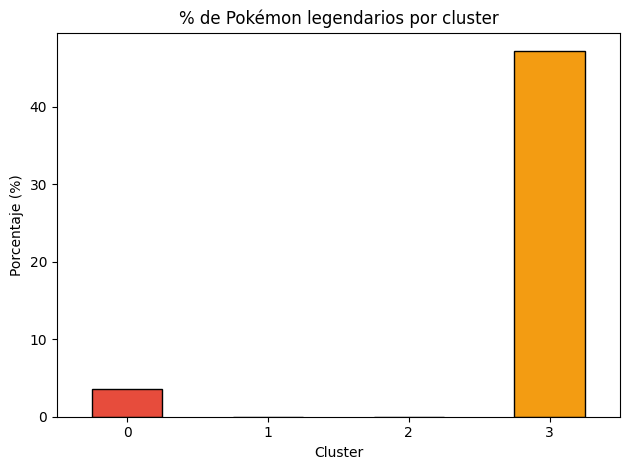

% legendarios por cluster:
Cluster
0     3.5
1     0.0
2     0.0
3    47.2
Name: Legendary, dtype: float64


In [ ]:
# Proporción de legendarios por cluster
leg_por_cluster = df.groupby("Cluster")["Legendary"].mean() * 100
leg_por_cluster.plot(kind="bar", color=colores[:K_OPTIMO], edgecolor="black")
plt.title("% de Pokémon legendarios por cluster")
plt.ylabel("Porcentaje (%)")
plt.xlabel("Cluster")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("% legendarios por cluster:")
print(leg_por_cluster.round(1))

In [20]:
# Tipos más frecuentes por cluster
for cid in range(K_OPTIMO):
    top_tipos = df[df["Cluster"] == cid]["Type 1"].value_counts().head(5)
    total = (df["Cluster"] == cid).sum()
    print(f"\n--- Cluster {cid} ({total} pokémon) — Tipos más comunes ---")
    print(top_tipos.to_string())


--- Cluster 0 (198 pokémon) — Tipos más comunes ---
Type 1
Water     37
Grass     20
Rock      20
Normal    16
Steel     14

--- Cluster 1 (279 pokémon) — Tipos más comunes ---
Type 1
Normal     42
Water      40
Bug        30
Grass      25
Psychic    18

--- Cluster 2 (200 pokémon) — Tipos más comunes ---
Type 1
Normal    31
Bug       23
Water     23
Fire      21
Grass     18

--- Cluster 3 (123 pokémon) — Tipos más comunes ---
Type 1
Dragon     19
Psychic    18
Fire       13
Water      12
Normal      9


In [21]:
# Algunos Pokémon representativos de cada cluster
print("Ejemplos de Pokémon por cluster:")
for cid in range(K_OPTIMO):
    ejemplos = df[df["Cluster"] == cid][["Name", "Type 1", "Total", "Legendary"]]
    print(f"\nCluster {cid}:")
    print(ejemplos.sort_values("Total", ascending=False).head(5).to_string(index=False))

Ejemplos de Pokémon por cluster:

Cluster 0:
               Name  Type 1  Total  Legendary
  AggronMega Aggron   Steel    630      False
SteelixMega Steelix   Steel    610      False
            Diancie    Rock    600       True
          Cresselia Psychic    600      False
DeoxysDefense Forme Psychic    600       True

Cluster 1:
     Name  Type 1  Total  Legendary
Gothorita Psychic    390      False
  Ariados     Bug    390      False
   Dustox     Bug    385      False
 Delcatty  Normal    380      False
  Sableye    Dark    380      False

Cluster 2:
      Name Type 1  Total  Legendary
   Haxorus Dragon    540      False
   Noivern Flying    535      False
    Crobat Poison    535      False
 Charizard   Fire    534      False
Typhlosion   Fire    534      False

Cluster 3:
                 Name  Type 1  Total  Legendary
  MewtwoMega Mewtwo X Psychic    780       True
  MewtwoMega Mewtwo Y Psychic    780       True
RayquazaMega Rayquaza  Dragon    780       True
  KyogrePrimal Kyog

## 6. Heatmap de centroides

Visualización directa de los centroides en el espacio estandarizado.

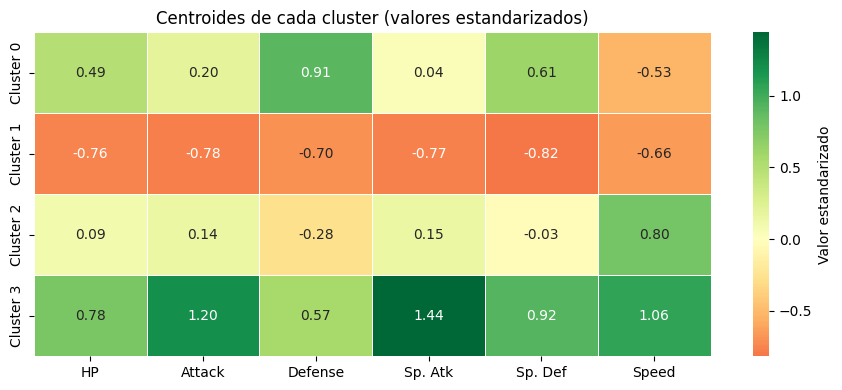

In [22]:
centroides_df = pd.DataFrame(kmeans.cluster_centers_, columns=stats_cols)
centroides_df.index = [f"Cluster {i}" for i in range(K_OPTIMO)]

plt.figure(figsize=(9, 4))
sns.heatmap(centroides_df, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, cbar_kws={"label": "Valor estandarizado"})
plt.title("Centroides de cada cluster (valores estandarizados)")
plt.tight_layout()
plt.show()

## Ejercicios

### Ejercicio 1 — Cambiar el número de clusters

In [23]:
# Probar con k=3 y k=6. Comparar los silhouette scores.
for k in [3, 6]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}: Silhouette={score:.4f}, Inercia={km.inertia_:.2f}")

k=3: Silhouette=0.2569, Inercia=2862.06
k=6: Silhouette=0.2146, Inercia=2190.85


### Ejercicio 2 — Clustering solo con Pokémon no legendarios

In [24]:
# Filtrar legendarios y aplicar K-Means (k=4) solo en pokémon normales
df_normal = df[df["Legendary"] == False].copy()
X_normal = StandardScaler().fit_transform(df_normal[stats_cols])

km_normal = KMeans(n_clusters=4, random_state=42, n_init=10)
df_normal["Cluster"] = km_normal.fit_predict(X_normal)

print(f"Pokémon no legendarios: {len(df_normal)}")
print("Tamaño de clusters:")
print(df_normal["Cluster"].value_counts().sort_index())
print("\nMedia de stats por cluster:")
df_normal.groupby("Cluster")[stats_cols].mean().round(1)

Pokémon no legendarios: 735
Tamaño de clusters:
Cluster
0    124
1    297
2    100
3    214
Name: count, dtype: int64

Media de stats por cluster:


,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
Cluster,,,,,,
0,102.2,93.8,78.3,77.6,79.9,58.9
1,50.7,55.0,52.5,48.9,50.0,50.0
2,66.9,93.5,123.2,68.2,89.1,53.9
3,69.8,85.5,70.0,90.5,79.3,96.1


### Desafío — Clustering con PCA previo

In [25]:
# Aplicar PCA (3 componentes) antes de K-Means y comparar silhouette
pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)
print(f"Varianza explicada con 3 PCs: {pca3.explained_variance_ratio_.sum()*100:.1f}%")

km_pca = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
labels_pca = km_pca.fit_predict(X_pca3)

sil_original = silhouette_score(X_scaled, kmeans.labels_)
sil_pca      = silhouette_score(X_pca3, labels_pca)

print(f"\nSilhouette — K-Means en 6D original: {sil_original:.4f}")
print(f"Silhouette — K-Means sobre PCA 3D:   {sil_pca:.4f}")

Varianza explicada con 3 PCs: 76.4%

Silhouette — K-Means en 6D original: 0.2154
Silhouette — K-Means sobre PCA 3D:   0.3069
